# Goal of this notebook is to find binary properties that work well for the full evolution

I.e., lab 1, give or take (find conservative case B mass transfer binary)
lab 3, sticking together through the end (have a binary that is on the edge of untstable mass transfer on the way back)

In [13]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.lines import Line2D

### Orbital evolution
Starting from the general eq for orbital evol
(pols lecture notes eq. 16.8)

$$
\frac{\dot{a}}{a} = -2\frac{\dot{M}_d}{M_d} \left[ 1 - \beta\frac{M_d}{M_a} - (1-\beta)\left(\gamma + \tfrac{1}{2}\right)\frac{M_d}{M_d + M_a} \right]
$$

Rewrite in terms of $q = M_d/M_a$:

$$
\frac{\dot{a}}{a} = -2\frac{\dot{M}_d}{M_d} \left[ 1 - \beta q - (1-\beta)\left(\gamma + \tfrac{1}{2}\right)\frac{q}{1+q} \right]
$$

Define the bracket as $f(q, \gamma)$ for compactness:

$$
f(q,\gamma) \equiv 1 - \beta q - (1-\beta)\left(\gamma + \tfrac{1}{2}\right)\frac{q}{1+q}
$$

So we can simplify

$$\frac{\dot{a}}{a} = -\frac{2\dot{M}_d}{M_d}\, f(q,\gamma) \tag{1}$$

***

Our goal is to eliminate $\dot{M}_d$ and just write the equation in terms of $da$ and $dq$ so we can integrate the orbital evolution assuming $beta$ is constant and without knowing $\dot{M}_d$ at every timestep

In order to do this we will need $\frac{\dot{q}}{q}$

The donor loses mass at rate $\dot{M}_d < 0$. The accretor gains a fraction $\beta$:
$$
\dot{M}_a = -\beta \dot{M}_d
$$

Now differentiate $q = M_d / M_a$:

$$
\dot{q} = \frac{\dot{M}_d}{M_a} - \frac{M_d}{M_a}\frac{\dot{M}_a}{M_a}
$$

Substitute $\dot{M}_a = -\beta \dot{M}_d$:

$$
\dot{q} = \frac{\dot{M}_d}{M_a} + \beta\frac{M_d}{M_a}\frac{\dot{M}_d}{M_a} = \frac{\dot{M}_d}{M_a}\left(1 + \beta q\right)
$$

From which we can get $\frac{\dot{q}}{q}$ by dividing both sides by $q = M_d/M_a$:

$$
 \frac{\dot{q}}{q} = \frac{\dot{M}_d}{M_d}\left(1 + \beta q\right) \tag{2}
$$

***

Divide equation (1) by equation (2):

$$
\frac{\dot{a}/a}{\dot{q}/q} = \frac{-2\dot{M}_d/M_d \cdot f(q,\gamma)}{\dot{M}_d/M_d \cdot (1 + \beta q)}
$$

The $\dot{M}_d/M_d$ cancels:

$$
\frac{\dot{a}/a}{\dot{q}/q} = \frac{-2\, f(q,\gamma)}{1 + \beta q} \tag{3}
$$

Also remember that 

$$
\frac{d\ln a}{a} = 1/a
$$

so we can use this to cancel out the dt 

$$
\frac{\dot{a}/a}{\dot{q}} = \frac{d \ln a}{dq} 
$$

and we end up with

$$
\frac{d\ln a}{d q} = \frac{-2\,f(q,\gamma)}{q(1 + \beta q)} \tag{4}
$$


$$
\boxed{\frac{d\ln a}{dq} = \frac{-2}{q(1+\beta q)}\left[1 - \beta q - (1-\beta)\left(\gamma+\tfrac{1}{2}\right)\frac{q}{1+q}\right]}
$$

This ODE depends only on $q$, $\beta$, and $\gamma$, **$\dot{M}_d$ dropped out entirely**.
Given an initial separation $a_0$ at $q = q_0$, you can integrate numerically to find $a(q)$ for any mass-transfer history, regardless of the Mdot.

### Gamma cases 

| Mode | $\gamma$ |
|---|---|
| Jeans (fast) | $\gamma = M_a/M_d = 1/q$ |
| Isotropic re-emission | $\gamma = M_d/M_a = q$ |
| Circumbinary ring | $\gamma = \dfrac{(M_d+M_a)^2}{M_d M_a}\sqrt{\dfrac{a_\mathrm{ring}}{a}} = \dfrac{(1+q)^2}{q}\sqrt{\dfrac{a_\mathrm{ring}}{a}}$ |

Note that for the ring case, $\gamma$ depends on $a$ itself, so it must be updated at each integration step (which the numerical code handles automatically).


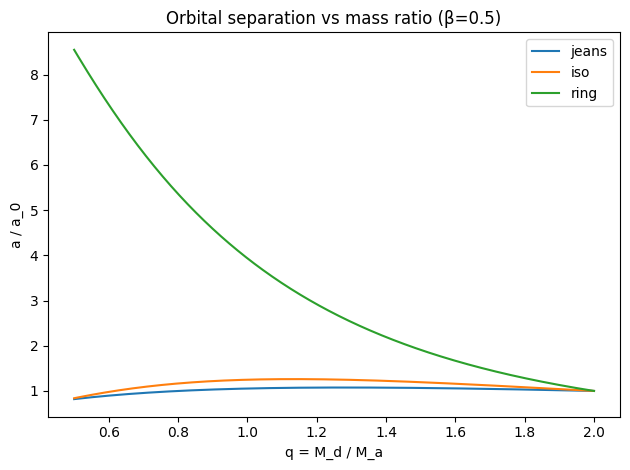

In [14]:
def dlna_dq(q, ln_a, beta, gamma_func, a_ring_over_a=None):
    """
    d(ln a)/dq as a function of q = M_d/M_a.

    Derived by dividing ȧ/a by q̇/q, so Ṁ_d cancels out.

    Parameters
    ----------
    q          : float - mass ratio M_d/M_a
    ln_a       : float - log of separation (state variable)
    beta       : float - accretion efficiency
    gamma_func : str   - one of 'jeans', 'iso', 'ring'
    a_ring_over_a : float - only needed for 'ring' mode
    """
    a = np.exp(ln_a[0])

    # Compute gamma
    if gamma_func == 'jeans':
        gamma = 1.0 / q          # gamma = M_a/M_d = 1/q
    elif gamma_func == 'iso':
        gamma = q                # gamma = M_d/M_a = q
    elif gamma_func == 'ring':
        gamma = ((1 + q)**2 / q) * np.sqrt(a_ring_over_a)
    else:
        raise ValueError(f"Unknown gamma_func: {gamma_func}")

    # d(ln a)/d(ln q): derived from ȧ/a divided by q̇/q
    # q̇/q = Ṁ_d/M_d - Ṁ_a/M_a = Ṁ_d/M_d * (1 + beta*q) / ... 
    # full result:
    numerator   = 2 * (1 - beta*q - (1 - beta)*(gamma + 0.5)*q/(1 + q))
    denominator = 1 + beta * q   # from dq/d(ln Md)

    dlna_dlnq = numerator / denominator

    # convert: d(ln a)/dq = d(ln a)/d(ln q) * (1/q)
    return [dlna_dlnq / q]


def integrate_separation(q_start, q_end, beta, gamma_func, a0=1.0,
                          a_ring_over_a=2.3, n_points=500):
    """
    Integrate orbital separation from q_start to q_end.

    Returns
    -------
    q_arr : array of mass ratios
    a_arr : array of separations (in units of a0)
    """
    ln_a0  = [np.log(a0)]
    q_span = (q_start, q_end)
    q_eval = np.linspace(q_start, q_end, n_points)

    sol = solve_ivp(
        fun=lambda q, y: dlna_dq(q, y, beta, gamma_func, a_ring_over_a),
        t_span=q_span,
        y0=ln_a0,
        t_eval=q_eval,
        method='RK45',
        rtol=1e-8, atol=1e-10
    )

    return sol.t, np.exp(sol.y[0])


# --- Example ---
# 45/23  P = 17.0  beta = 0.75
q_i, q_f = 2.0, 0.5   # donor starts more massive, ends less massive
beta      = 0.5

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for mode in ['jeans', 'iso', 'ring']:
    q_arr, a_arr = integrate_separation(q_i, q_f, beta=beta, gamma_func=mode)
    ax.plot(q_arr, a_arr, label=mode)

ax.set_xlabel('q = M_d / M_a')
ax.set_ylabel('a / a_0')
ax.legend()
ax.set_title(f'Orbital separation vs mass ratio (β={beta})')
plt.tight_layout()
plt.show()

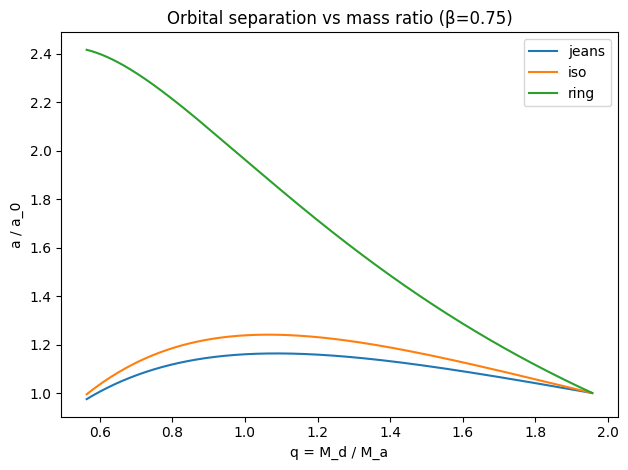

In [15]:
# --- Example ---
m1_i, m2_i = 45, 23
q_i = m1_i / m2_i
# qstart = 45/23 

# P start = 17.0  
beta = 0.75
# qfinal = 0.5*45/ (23 + 0.75*45*0.5)
q_f = (0.5*m1_i)/ (m2_i + beta *m1_i*0.5)

# q_i, q_f = 2.0, 0.5   # donor starts more massive, ends less massive

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for mode in ['jeans', 'iso', 'ring']:
    q_arr, a_arr = integrate_separation(q_i, q_f, beta=beta, gamma_func=mode)
    ax.plot(q_arr, a_arr, label=mode)

ax.set_xlabel('q = M_d / M_a')
ax.set_ylabel('a / a_0')
ax.legend()
ax.set_title(f'Orbital separation vs mass ratio (β={beta})')
plt.tight_layout()
plt.show()


 # Finding conservative case-B mass transfer anchors in the post-MT catalog

 ## Goal
 Identify observed massive post-MT binaries that serve as evidence for
 **conservative case-B mass transfer**, 
 then determine approximate pre-MT conditions for MESA
 (M1_ZAMS, M2_ZAMS, P_ZAMS, beta) that reproduce them 
 
 — with the requirement that the system is a BBH progenitor going through two stable MT phases.

 ## Strategy
 1. Load the catalog 
 2. Filter for WR+O binaries and massive Algols.
 4. Predict post-MT outcomes for a grid of (M1_i, M2_i, P_i, beta) using a
    semi-analytic treatment (He core mass ~ 0.4 M_ZAMS, integrate
    d ln a / dq numerically for non-conservative MT).
 5. Plot observed vs predicted in (M_WR, M_O) and (M_tot, P) space.

In [16]:
catalog_dir = '/Users/liekevanson/Documents/Projects/post_mt_review/data/'
catalog_file = f'{catalog_dir}post_mt_systems.json'

## 1. Load the catalog into a flat DataFrame
Catalog entries store values as `[low_err, central, high_err]` lists;
`central()` pulls out the central value robustly.


In [17]:

def central(x):
    """Extract central value from [low_err, value, high_err] list or scalar."""
    if x is None:
        return np.nan
    if isinstance(x, list):
        if len(x) >= 2:
            return x[1] if x[1] is not None else np.nan
        return x[0] if x[0] is not None else np.nan
    return x


def load_catalog(path):
    with open(path) as f:
        data = json.load(f)
    rows = []
    for d in data:
        rows.append({
            'name':  d['System Name'],
            'class': d['system_class'],
            'M1':    central(d.get('M1')),
            'M2':    central(d.get('M2')),
            'P':     central(d.get('Period')),
            'e':     central(d.get('Eccentricity')),
            'obs1':  d.get('obs_type_1'),
            'obs2':  d.get('obs_type_2'),
            'evol1': d.get('evol_type_1'),
            'evol2': d.get('evol_type_2'),
        })
    return pd.DataFrame(rows)

df = load_catalog(catalog_file)
print(f"Total systems: {len(df)}")
print("\nSystem classes:")
print(df['class'].value_counts())


Total systems: 4763

System classes:
class
Astrometric WD + MS             3137
WD + MS                          446
Spectroscopic WD + MS            365
high-mass XRB                    162
Hot subdwarf binary              146
Algol                            126
Chemically Peculiar               82
Post-AGB binary                   77
EL CVn                            65
WR binary                         45
Contact binary                    27
Astrometric compact object        24
Blue straggler binary             22
Spectroscopic compact object      14
pulsar binary                      9
Intermediate-M stripped star       8
He giant                           4
Symbiotic XRB                      3
Self-lensing WD + MS               1
Name: count, dtype: int64



## 2. Extract WR+O systems
Convention in the output: 
`M_WR` = mass of the He-star (former donor),
`M_O` = mass of the O-star (accretor).

In [18]:
wr = df[df['class'] == 'WR binary'].dropna(subset=['M1', 'M2', 'P']).copy()
wr = wr.rename(columns={'M2': 'M_WR', 'M1': 'M_O'})
wr['M_tot'] = wr['M_WR'] + wr['M_O']
print(f"WR+O binaries with both masses measured: {len(wr)}")

WR+O binaries with both masses measured: 20


 ## 3. Apply cuts for BBH-progenitor relevance


In [19]:
# looking for high-mass (companion > 20) to still form BH
bbh_progen_mask = (wr['M_tot'] > 30) # & (wr['P'] < 50) 
wr_bbh = wr[bbh_progen_mask].sort_values('P')

print(f"WR+O systems with Mtot > 30: {len(wr_bbh)}")
print(wr_bbh[['name', 'M_WR', 'M_O', 'M_tot', 'P', 'e', 'obs1', 'obs2']]
      .to_string(index=False))

# Also grab high-mass Algols for context (semi-detached, mid-MT systems)
algol = df[df['class'] == 'Algol'].copy()
algol = algol.dropna(subset=['M1', 'M2', 'P'])
algol_mask = (algol['M1'] + algol['M2'] > 20) #& (algol['P'] < 50)
algol_hm = algol[algol_mask].copy()
print(f"\nHigh-mass Algols: {len(algol_hm)}")
print(algol_hm[['name', 'M2', 'M1', 'P', 'e', 'obs1', 'obs2']].to_string(index=False))

WR+O systems with Mtot > 30: 18
     name  M_WR   M_O  M_tot           P      e     obs1      obs2
   WR 155 27.60 24.50  52.10    1.641244 0.0100      WN6   O9II-Ib
   WR 151 28.90 20.40  49.30    2.126870 0.0000      WN4       O5V
BAT99 129 16.00 27.00  43.00    2.768700 0.0000     O4 V    WR-WN5
   WR 139 26.40 10.70  37.10    4.212500 0.0000      WN5   O6III-V
    WR 47 50.40 41.80  92.20    6.239300 0.0000      WN6       O5V
 SMC AB 6 18.00 41.00  59.00    6.538400 0.0000 O-O5.5 V    WR-WN3
    WR 42 23.00 14.00  37.00    7.886000 0.0000      WC7       O7V
    WR 21 37.00 19.00  56.00    8.254600 0.0400      WN5      O4-6
   WR 127 30.90 21.20  52.10    9.555000 0.0000      WN3     O9.5V
     WR 9 32.00  9.00  41.00   14.305000 0.0000      WC5        O7
 BAT99 19 22.00 40.00  62.00   17.994000 0.0200     O6 V    WR-WN4
    WR 30 34.00 16.00  50.00   18.820000    NaN      WC6      O6-8
 SMC AB 8 19.00 61.00  80.00   19.560000 0.1000   O-O4 V    WR-WO4
 SMC AB 7 23.00 44.00  67.00  

## 4. Predict post-MT outcomes for a (M1_i, M2_i, P_i, beta) grid

### We make the following assumptions:
- Donor is stripped to its He core: $M_\mathrm{He} \approx  f_{core} \,M_\mathrm{ZAMS}$
- Accretor gains $\beta \cdot \Delta M$ of the transferred material.
- Orbital response:
  - **Conservative (β=1):** $a_f/a_i = (M_{1,i} M_{2,i}/(M_{1,f} M_{2,f}))^2$
  - **Partially conservative:** integrate $d\ln a / dq$ with isotropic re-emission
    for the fraction $(1-\beta)$ lost from the accretor.
- Period: $P \propto a^{3/2} / \sqrt{M_\mathrm{tot}}$

In [20]:
def predict_post_mt(Md_i, Ma_i, P_i, beta, frac_core=0.5):
    """
    Predict the post case-B MT state.

    Parameters
    ----------
    Md_i, Ma_i : Msun  (donor, accretor)
    P_i        : days
    beta       : fraction of transferred mass accreted (1 = fully conservative)
    frac_core  : fraction of Md_ZAMS that remains as He-core after stripping

    Returns
    -------
    Md_f, Ma_f, P_f
    """
    # Final masses 
    Md_f = frac_core * Md_i
    dM   = Md_i - Md_f
    Ma_f = Ma_i + beta * dM

    q_i   = Md_i / Ma_i 
    q_f   = Md_f / Ma_f

    if beta == 1.0:
        a_ratio = (Md_i * Ma_i / (Md_f * Ma_f))**2
        # Change separation to period using Kepler
        P_ratio = a_ratio**1.5

    else:
        # Integrate d ln a / dq assuming isotropic re-emission for the lost fraction
        def dlna_dq(q, lna):
            gamma = q                                           # iso re-emission
            f = 1 - beta*q - (1-beta)*(gamma + 0.5)*q/(1+q)
            return [-2*f / (q*(1 + beta*q))]

        sol = solve_ivp(dlna_dq, (q_i, q_f), [0.0], rtol=1e-8)
        a_ratio = np.exp(sol.y[0, -1])

        # Change separation to period using Kepler
        Mtot_i = Md_i + Ma_i
        Mtot_f = Md_f + Ma_f
        P_ratio = (a_ratio**3 * Mtot_i / Mtot_f)**0.5

    return Md_f, Ma_f, P_i * P_ratio



### Generate a set of scenarios varying (M1_i, M2_i), P_i and beta

In [21]:
scenarios = []
for M1_i, M2_i in [(35, 28), (40, 30)]:
    # we are only looking for non-zero beta 
    for beta in [0.25, 0.5, 0.75, 1.0]:
        for P_i in [5, 10, 15, 20]:
            M1_f, M2_f, P_f = predict_post_mt(M1_i, M2_i, P_i, beta)
            scenarios.append({
                'M1_i': M1_i, 'M2_i': M2_i, 'P_i': P_i, 'beta': beta,
                'M_WR_pred': M1_f, 'M_O_pred': M2_f, 'P_pred': P_f,
                'M_tot_pred': M1_f + M2_f,
            })
scen = pd.DataFrame(scenarios)
print(scen.to_string(index=False))


 M1_i  M2_i  P_i  beta  M_WR_pred  M_O_pred    P_pred  M_tot_pred
   35    28    5  0.25       17.5    32.375 11.177748      49.875
   35    28   10  0.25       17.5    32.375 22.355495      49.875
   35    28   15  0.25       17.5    32.375 33.533243      49.875
   35    28   20  0.25       17.5    32.375 44.710991      49.875
   35    28    5  0.50       17.5    36.750 10.552265      54.250
   35    28   10  0.50       17.5    36.750 21.104531      54.250
   35    28   15  0.50       17.5    36.750 31.656796      54.250
   35    28   20  0.50       17.5    36.750 42.209062      54.250
   35    28    5  0.75       17.5    41.125  9.926219      58.625
   35    28   10  0.75       17.5    41.125 19.852437      58.625
   35    28   15  0.75       17.5    41.125 29.778656      58.625
   35    28   20  0.75       17.5    41.125 39.704874      58.625
   35    28    5  1.00       17.5    45.500  9.321802      63.000
   35    28   10  1.00       17.5    45.500 18.643605      63.000
   35    2

### Best-match scan: find initial conditions per observed target


In [8]:
def chi2_match(M_WR_pred, M_O_pred, P_pred, M_WR_obs, M_O_obs, P_obs):
    """Simple chi square metric in log/fractional space."""
    return (((M_WR_pred - M_WR_obs) / M_WR_obs)**2
            + ((M_O_pred - M_O_obs) / M_O_obs)**2
            + (np.log10(P_pred / P_obs))**2)


def find_best_match(M_WR_obs, M_O_obs, P_obs,
                    M1_range=np.arange(15, 60, 2),
                    M2_range=np.arange(10, 40, 1),
                    P_range=np.arange(2, 30, 0.5),
                    beta_range=(0.25, 0.5, 0.75, 1.0)):
    best = (np.inf, None)
    for M1_i in M1_range:
        for M2_i in M2_range:
            if M2_i >= M1_i:
                continue
            for P_i in P_range:
                for beta in beta_range:
                    try:
                        M1_f, M2_f, P_f = predict_post_mt(M1_i, M2_i, P_i, beta)
                    except Exception:
                        continue
                    chi = chi2_match(M1_f, M2_f, P_f, M_WR_obs, M_O_obs, P_obs)
                    if chi < best[0]:
                        best = (chi, (M1_i, M2_i, P_i, beta, M1_f, M2_f, P_f))
    return best


def build_targets_from_names(selected_names, wr_df, algol_df):
    """Build (name, M_WR_obs, M_O_obs, P_obs) tuples from wr_bbh + algol_hm.

    For Algols, we map the lighter component to M_WR_obs and the heavier to M_O_obs
    so the tuple format stays consistent with the WR+O convention.
    """
    wr_lookup = {
        row['name']: (row['M_WR'], row['M_O'], row['P'])
        for _, row in wr_df[['name', 'M_WR', 'M_O', 'P']].dropna().iterrows()
    }
    algol_lookup = {
        row['name']: (min(row['M1'], row['M2']), max(row['M1'], row['M2']), row['P'])
        for _, row in algol_df[['name', 'M1', 'M2', 'P']].dropna().iterrows()
    }

    targets_local = []
    missing = []

    for name in selected_names:
        if name in wr_lookup:
            m_wr, m_o, p = wr_lookup[name]
            targets_local.append((name, float(m_wr), float(m_o), float(p)))
        elif name in algol_lookup:
            m_wr, m_o, p = algol_lookup[name]
            targets_local.append((name, float(m_wr), float(m_o), float(p)))
        else:
            missing.append(name)

    if missing:
        print('Names not found in wr_bbh or algol_hm:')
        for n in missing:
            print(f'  - {n}')

    return targets_local


print('Available WR+O names (wr_bbh):')
print(sorted(wr_bbh['name'].dropna().unique().tolist()))
print('\nAvailable Algol names (algol_hm):')
print(sorted(algol_hm['name'].dropna().unique().tolist()))

# Pick names from wr_bbh and/or algol_hm here:
selected_names = [
    'BAT99 19',
    'SMC AB 7',
    'SMC AB 6',
    'WR 127',
    'BAT99 129',
    'V448 Cyg',
]

targets = build_targets_from_names(selected_names, wr_bbh, algol_hm)

print('\nTargets used for fitting:')
for t in targets:
    print(t)

print('\nBest-matching ZAMS conditions per target:')
print(f"{'Target':12s} | {'M1_i':>4s} {'M2_i':>4s} {'P_i':>5s} {'beta':>4s} "
      f"-> {'M_WR_f':>6s} {'M_O_f':>6s} {'P_f':>7s}")
for name, M_WR_obs, M_O_obs, P_obs in targets:
    chi, res = find_best_match(M_WR_obs, M_O_obs, P_obs)
    M1i, M2i, Pi, b, M1f, M2f, Pf = res
    print(f"{name:12s} | {M1i:4.0f} {M2i:4.0f} {Pi:5.1f} {b:4.2f} "
          f"-> {M1f:6.1f} {M2f:6.1f} {Pf:7.2f} d  (obs: {M_WR_obs}, {M_O_obs}, {P_obs})")

Available WR+O names (wr_bbh):
['BAT99 129', 'BAT99 19', 'SMC AB 6', 'SMC AB 7', 'SMC AB 8', 'WR 11', 'WR 113', 'WR 127', 'WR 133', 'WR 139', 'WR 140', 'WR 151', 'WR 155', 'WR 21', 'WR 30', 'WR 42', 'WR 47', 'WR 9']

Available Algol names (algol_hm):
['AB Cru', 'AQ Cas', 'HH Car', 'HV 2241', 'HV 2543', 'QZ Car', 'V337 Aql', 'V448 Cyg', 'VFTS 061', 'VFTS 450', 'VFTS 538', 'VFTS 652', 'W61 28-22', 'del Pic']

Targets used for fitting:
('BAT99 19', 22.0, 40.0, 17.994)
('SMC AB 7', 23.0, 44.0, 19.56)
('SMC AB 6', 18.0, 41.0, 6.5384)
('WR 127', 30.9, 21.2, 9.555)
('BAT99 129', 16.0, 27.0, 2.7687)
('V448 Cyg', 13.699999809265137, 24.700000762939453, 6.5197162)

Best-matching ZAMS conditions per target:
Target       | M1_i M2_i   P_i beta -> M_WR_f  M_O_f     P_f
BAT99 19     |   45   23  17.0 0.75 ->   22.5   39.9   17.89 d  (obs: 22.0, 40.0, 17.994)
SMC AB 7     |   45   27  14.5 0.75 ->   22.5   43.9   19.57 d  (obs: 23.0, 44.0, 19.56)
SMC AB 6     |   35   23   4.5 1.00 ->   17.5   40.5  

## 5. Visualize: observed vs predicted in mass and period space


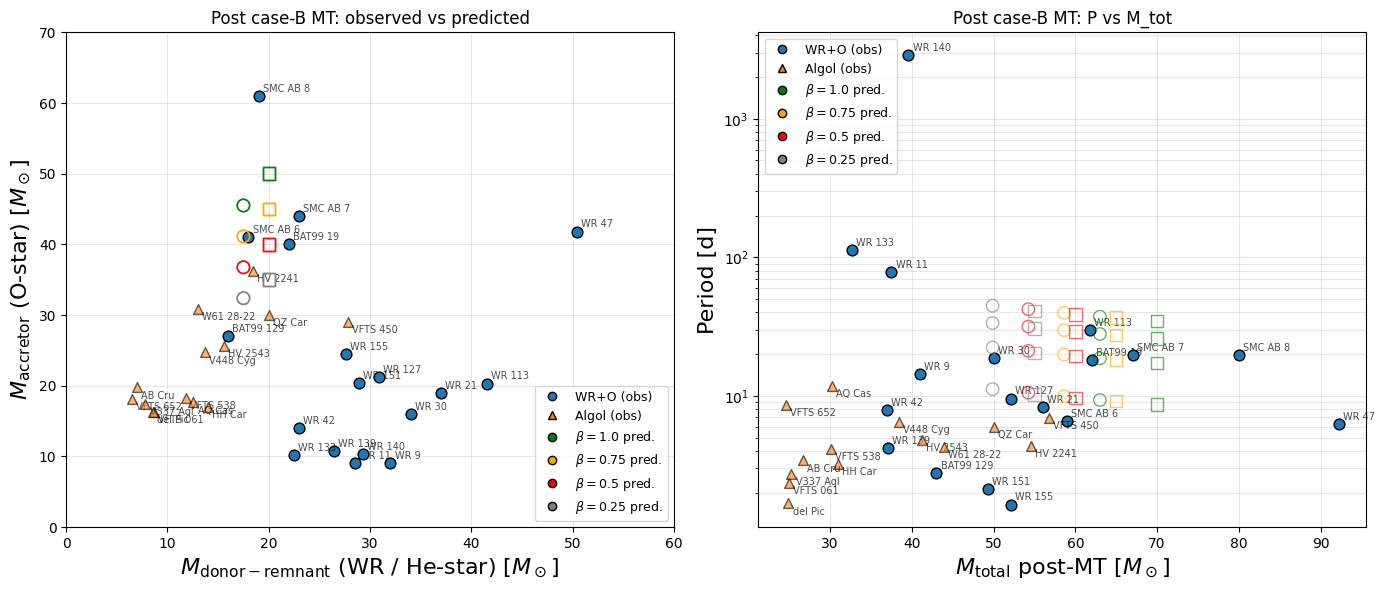

In [33]:
def plot_observed_vs_predicted(wr, algol_hm, scen, savepath=None):
    """Compare observed systems against predicted post-MT scenarios.

    Parameters
    ----------
    wr : DataFrame
        Observed WR+O systems with columns:
        ['name', 'M_WR', 'M_O', 'M_tot', 'P'].
    algol_hm : DataFrame
        Observed high-mass Algols with columns:
        ['name', 'M1', 'M2', 'P'].
    scen : DataFrame
        Predicted scenarios generated earlier in the notebook. Required keys:
        ['M1_i', 'M2_i', 'beta', 'M_WR_pred', 'M_O_pred', 'M_tot_pred', 'P_pred'].
        - M1_i, M2_i: initial masses used to define marker shape
        - beta: accretion efficiency used to define marker color
        - *_pred: predicted post-MT observables
    savepath : str or None
        Optional output filename for saving the figure.
    """

    # Guardrail so the plotting failure message is clearer than a KeyError later.
    required_scen_cols = {
        'M1_i', 'M2_i', 'beta', 'M_WR_pred', 'M_O_pred', 'M_tot_pred', 'P_pred'
    }
    missing_cols = required_scen_cols.difference(scen.columns)
    if missing_cols:
        raise ValueError(f"scen is missing required columns: {sorted(missing_cols)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Visual encoding for model points: color = beta, marker = initial mass pair.
    beta_colors = {0.5: 'red', 0.75: 'orange', 1.0: 'green'}
    ic_markers = {(35, 28): 'o', (40, 30): 's'}

    # --- Left panel: remnant donor mass vs accretor mass ---
    ax = axes[0]

    # Observed WR+O points.
    for _, r in wr.iterrows():
        ax.scatter(r['M_WR'], r['M_O'], c='C0', s=60, edgecolor='k', zorder=3)
        ax.annotate(r['name'], (r['M_WR'], r['M_O']), fontsize=7, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    # Observed Algol points, mapped to the same (lighter, heavier) mass plane.
    for _, r in algol_hm.iterrows():
        x_algol = min(r['M1'], r['M2'])
        y_algol = max(r['M1'], r['M2'])
        ax.scatter(x_algol, y_algol,
                   c='C1', marker='^', s=50, edgecolor='k', zorder=3, alpha=0.6)
        ax.annotate(r['name'], (x_algol, y_algol), fontsize=7, alpha=0.7,
                    xytext=(3, -8), textcoords='offset points')

    # Predicted post-MT points from scen.
    for _, s in scen.iterrows():
        marker = ic_markers.get((s['M1_i'], s['M2_i']), 'x')
        color = beta_colors.get(s['beta'], 'gray')
        ax.scatter(s['M_WR_pred'], s['M_O_pred'],
                   edgecolor=color,
                   c = 'none',
                   marker=marker,
                   s=80, alpha=0.6, zorder=4)

    ax.set_xlabel(r'$M_\mathrm{donor-remnant}$ (WR / He-star) [$M_\odot$]', fontsize = 16)
    ax.set_ylabel(r'$M_\mathrm{accretor}$ (O-star) [$M_\odot$]', fontsize = 16)
    ax.set_title('Post case-B MT: observed vs predicted')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 70)

    # --- Right panel: total mass vs period ---
    ax = axes[1]

    # Observed WR+O points.
    for _, r in wr.iterrows():
        ax.scatter(r['M_tot'], r['P'], c='C0', s=60, edgecolor='k', zorder=3)
        ax.annotate(r['name'], (r['M_tot'], r['P']), fontsize=7, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    # Observed Algol points.
    for _, r in algol_hm.iterrows():
        x_algol = r['M1'] + r['M2']
        y_algol = r['P']
        ax.scatter(x_algol, y_algol,
                   c='C1', marker='^', s=50, edgecolor='k', zorder=3, alpha=0.6)
        ax.annotate(r['name'], (x_algol, y_algol), fontsize=7, alpha=0.7,
                    xytext=(3, -8), textcoords='offset points')

    # Predicted post-MT points from scen.
    for _, s in scen.iterrows():
        marker = ic_markers.get((s['M1_i'], s['M2_i']), 'x')
        color = beta_colors.get(s['beta'], 'gray')
        ax.scatter(s['M_tot_pred'], s['P_pred'],
                   edgecolor=color,
                   c = 'none',
                   marker=marker,
                   s=80, alpha=0.6, zorder=4)

    ax.set_xlabel(r'$M_\mathrm{total}$ post-MT [$M_\odot$]', fontsize = 16)
    ax.set_ylabel('Period [d]', fontsize = 16)
    ax.set_yscale('log')
    ax.set_title('Post case-B MT: P vs M_tot')
    ax.grid(alpha=0.3, which='both')

    # Legend summarizes marker semantics, not individual system names.
    legend_el = [
        Line2D([0], [0], marker='o', color='w', mfc='C0', mec='k', label='WR+O (obs)'),
        Line2D([0], [0], marker='^', color='w', mfc='C1', mec='k', label='Algol (obs)'),
        Line2D([0], [0], marker='o', color='w', mfc='green', mec='k', label=r'$\beta=1.0$ pred.'),
        Line2D([0], [0], marker='o', color='w', mfc='orange', mec='k', label=r'$\beta=0.75$ pred.'),
        Line2D([0], [0], marker='o', color='w', mfc='red', mec='k', label=r'$\beta=0.5$ pred.'),
        Line2D([0], [0], marker='o', color='w', mfc='gray', mec='k', label=r'$\beta=0.25$ pred.'),
    ]
    axes[0].legend(handles=legend_el, loc='lower right', fontsize=9)
    axes[1].legend(handles=legend_el, loc='upper left', fontsize=9)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=130, bbox_inches='tight')
    plt.show()
    return 


plot_observed_vs_predicted(wr_bbh, algol_hm, scen, savepath='case_B_targets.png')